In [1]:
PATH_WORK_DIR = ".."

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.chdir(PATH_WORK_DIR)
print(f"DIRECTORY: {os.getcwd()}")

DIRECTORY: c:\Users\jayar\Desktop\바탕 화면\REPO\PROJECT\M2-PJT_TXT


In [4]:
import sys
sys.path.append("src")

# packages

In [5]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from pymyproject import factor_analysis

# data

In [6]:
DATA_PATH = "./data/topic_monthly.csv"
df = pd.read_csv(DATA_PATH)

In [7]:
DATE_COL = "date"
df[DATE_COL] = pd.to_datetime(df[DATE_COL]).dt.to_period("M")
df = (
    df
    .set_index(DATE_COL)
    .sort_index(ascending=True)
)

In [8]:
df.head()

,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8,topic_9,topic_10,topic_11,topic_12,topic_13,topic_14,topic_15,topic_16,topic_17,topic_18,topic_19,topic_20
date,,,,,,,,,,,,,,,,,,,,
1948-05,0.195247,0.000057,0.000057,0.000057,0.000057,0.000057,0.000057,0.000057,0.000057,0.478024,0.000057,0.000057,0.000057,0.000057,0.000057,0.000057,0.000057,0.000057,0.325752,0.000057
1948-06,0.262050,0.000177,0.000046,0.003197,0.000046,0.006663,0.016634,0.000046,0.026970,0.570274,0.019700,0.002290,0.003172,0.001227,0.000115,0.000046,0.026826,0.000046,0.060230,0.000248
1948-07,0.226050,0.000028,0.005481,0.029609,0.000028,0.002706,0.021731,0.001920,0.019572,0.513749,0.006545,0.008788,0.007256,0.004700,0.000028,0.000028,0.091596,0.000028,0.060127,0.000028
1948-08,0.169135,0.000961,0.003036,0.000036,0.000036,0.001960,0.004173,0.002569,0.078797,0.670877,0.000756,0.000462,0.002676,0.004893,0.000126,0.000036,0.002651,0.000036,0.056749,0.000036
1948-09,0.141066,0.000667,0.000482,0.000153,0.000051,0.004024,0.010230,0.000593,0.120810,0.508681,0.127218,0.000287,0.001029,0.021415,0.000051,0.000130,0.030720,0.000051,0.032291,0.000051


In [ ]:
DROP_TOPICS = [
    "topic_2",
    "topic_5",
    "topic_8",
    "topic_18",
]
COND = df.columns.isin(DROP_TOPICS)
df = df.loc[:, ~COND]

TOPIC_COLS = list(df.columns)
df[TOPIC_COLS] = (
    df[TOPIC_COLS]
    .div(df[TOPIC_COLS].sum(axis=1), axis=0)
)

In [11]:
df.head()

,topic_1,topic_3,topic_4,topic_6,topic_7,topic_9,topic_10,topic_11,topic_12,topic_13,topic_14,topic_15,topic_16,topic_17,topic_19,topic_20
date,,,,,,,,,,,,,,,,
1948-05,0.195291,0.000057,0.000057,0.000057,0.000057,0.000057,0.478134,0.000057,0.000057,0.000057,0.000057,0.000057,0.000057,0.000057,0.325827,0.000057
1948-06,0.262132,0.000046,0.003198,0.006665,0.016639,0.026979,0.570453,0.019706,0.002290,0.003173,0.001227,0.000115,0.000046,0.026835,0.060249,0.000248
1948-07,0.226504,0.005492,0.029669,0.002711,0.021774,0.019611,0.514781,0.006558,0.008805,0.007271,0.004710,0.000028,0.000028,0.091780,0.060248,0.000028
1948-08,0.169746,0.003047,0.000036,0.001967,0.004188,0.079082,0.673302,0.000759,0.000464,0.002686,0.004911,0.000126,0.000036,0.002660,0.056954,0.000036
1948-09,0.141258,0.000483,0.000154,0.004030,0.010244,0.120974,0.509374,0.127392,0.000287,0.001030,0.021444,0.000051,0.000131,0.030762,0.032335,0.000051


# modeling

In [12]:
NUM_FACTORS = range(1,9)
SEED = 42

In [13]:
kwargs = dict(
    df=df,
    num_factors=NUM_FACTORS,
    seed=SEED,
)
result = factor_analysis.fa.main(**kwargs)

NUM FACTOR: 1	LIKELIHOOD: -20.2594
NUM FACTOR: 2	LIKELIHOOD: -19.8041
NUM FACTOR: 3	LIKELIHOOD: -19.5001
NUM FACTOR: 4	LIKELIHOOD: -19.3968
NUM FACTOR: 5	LIKELIHOOD: -19.2916
NUM FACTOR: 6	LIKELIHOOD: -19.2165
NUM FACTOR: 7	LIKELIHOOD: -19.1432
NUM FACTOR: 8	LIKELIHOOD: -19.0623
FACTOR ANALYSIS FINISHED


# vis obj

In [14]:
factor_loadings = dict()
factor_scores = dict()

# log likelihood

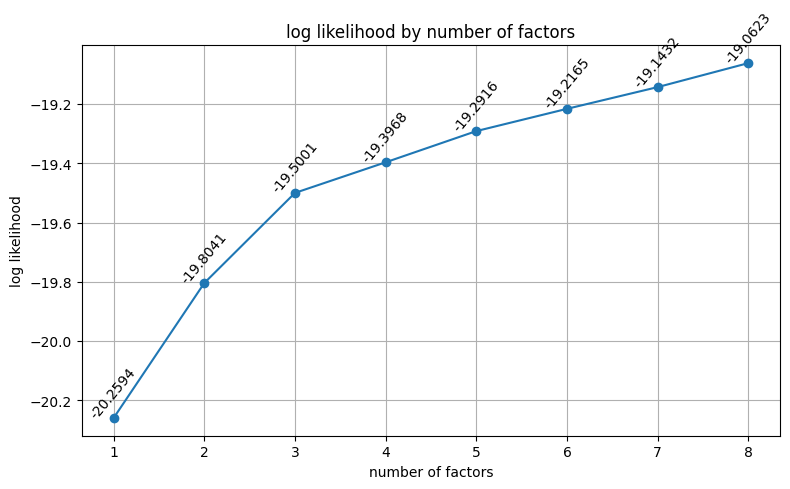

In [15]:
log_likelihood = factor_analysis.vis.plot_log_likelihood(result, (8,5))
plt.show()

# k=1

In [16]:
NUM_FACTORS = 1
loadings = result[NUM_FACTORS]["loadings"]
print(loadings)

          factor_1
topic             
topic_1   0.591363
topic_3  -0.017323
topic_4   0.244157
topic_6  -0.669096
topic_7   0.122471
topic_9   0.746757
topic_10  0.616230
topic_11  0.560445
topic_12 -0.599880
topic_13 -0.504370
topic_14  0.622725
topic_15 -0.734324
topic_16 -0.761329
topic_17  0.866740
topic_19 -0.153898
topic_20 -0.535136


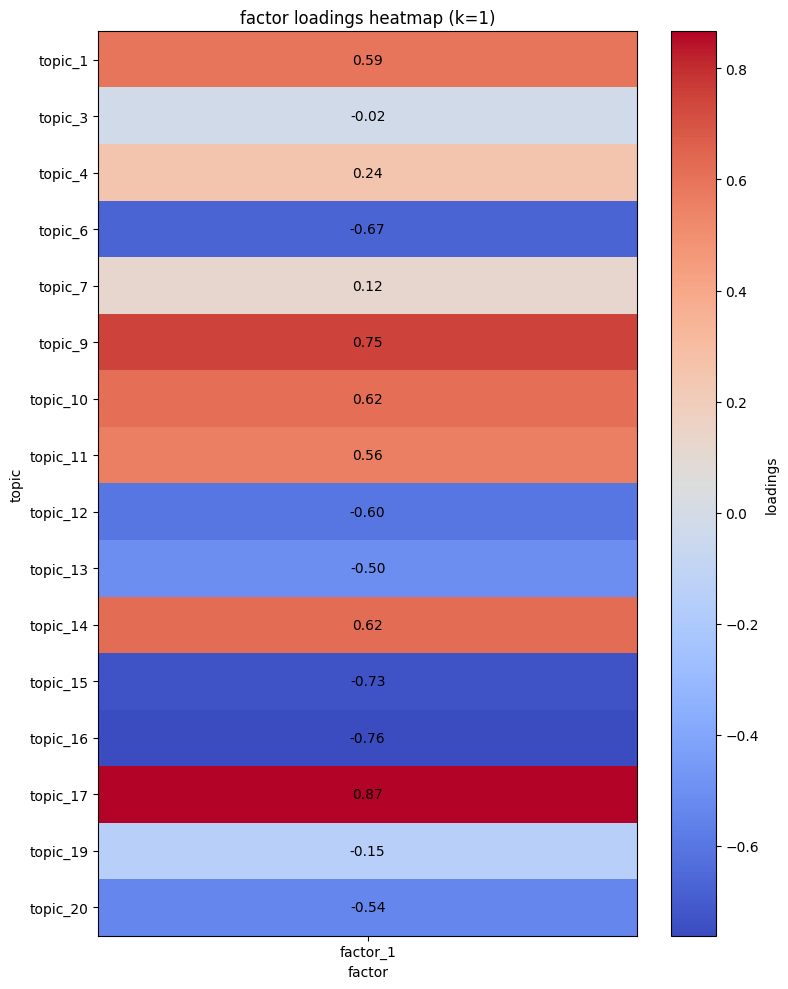

In [17]:
NUM_FACTORS = 1
FIGSIZE = (8,10)

kwargs = dict(
    result=result,
    num_factors=NUM_FACTORS,
    figsize=FIGSIZE,
)

factor_loadings[NUM_FACTORS] = factor_analysis.vis.plot_factor_loadings(**kwargs)
plt.show()

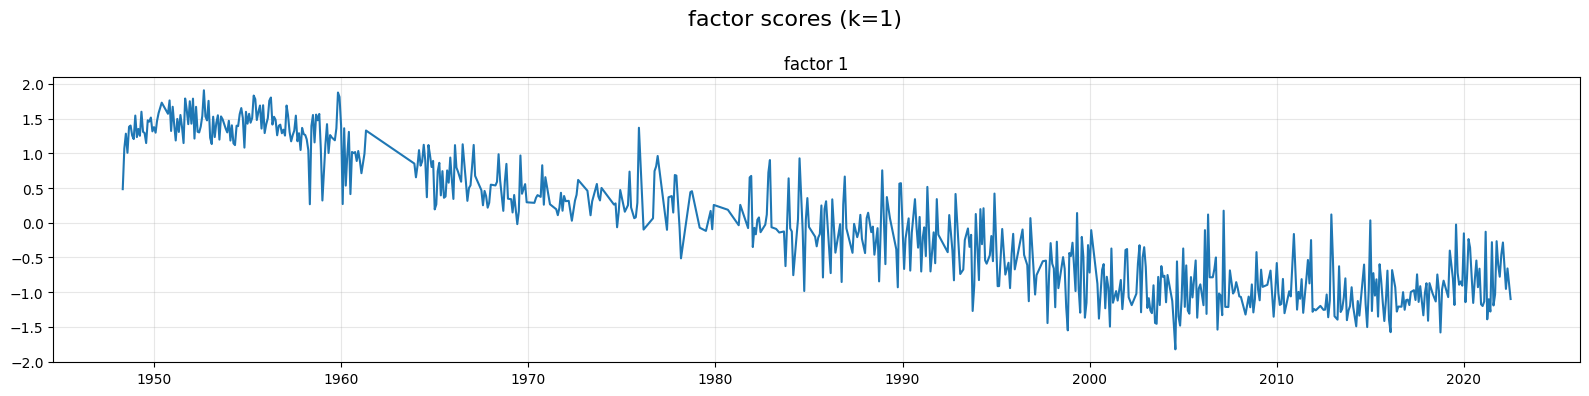

In [18]:
NUM_FACTORS = 1
FIGSIZE = (8,10)

kwargs = dict(
    result=result,
    num_factors=NUM_FACTORS,
)

factor_loadings[NUM_FACTORS] = factor_analysis.vis.plot_factor_scores(**kwargs)
plt.show()

# k=2

In [19]:
NUM_FACTORS = 2
loadings = result[NUM_FACTORS]["loadings"]
print(loadings)

          factor_1  factor_2
topic                       
topic_1   0.593530  0.117914
topic_3   0.005517  0.716730
topic_4   0.236761 -0.103942
topic_6  -0.655100 -0.019805
topic_7   0.142422  0.472477
topic_9   0.744438 -0.149472
topic_10  0.610605 -0.195856
topic_11  0.546675 -0.009181
topic_12 -0.581772  0.120239
topic_13 -0.496308  0.359404
topic_14  0.619569  0.002847
topic_15 -0.739524 -0.196996
topic_16 -0.804919 -0.390033
topic_17  0.881387 -0.254584
topic_19 -0.152075 -0.122738
topic_20 -0.541773 -0.170348


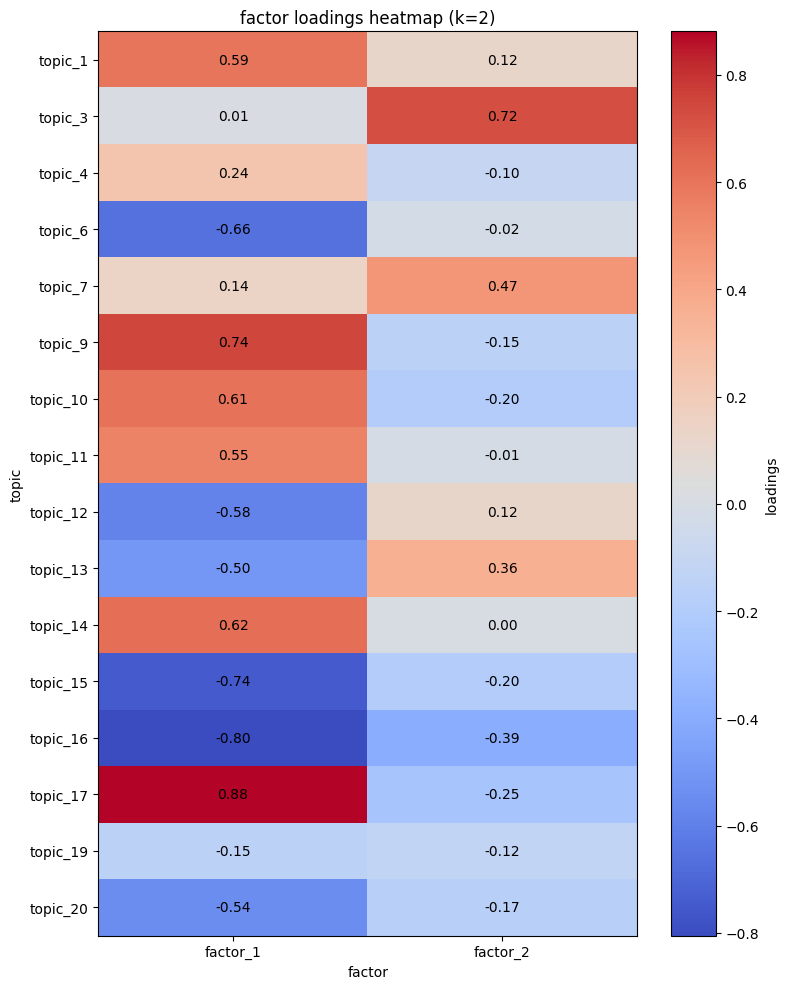

In [20]:
NUM_FACTORS = 2
FIGSIZE = (8,10)

kwargs = dict(
    result=result,
    num_factors=NUM_FACTORS,
    figsize=FIGSIZE,
)

factor_loadings[NUM_FACTORS] = factor_analysis.vis.plot_factor_loadings(**kwargs)
plt.show()

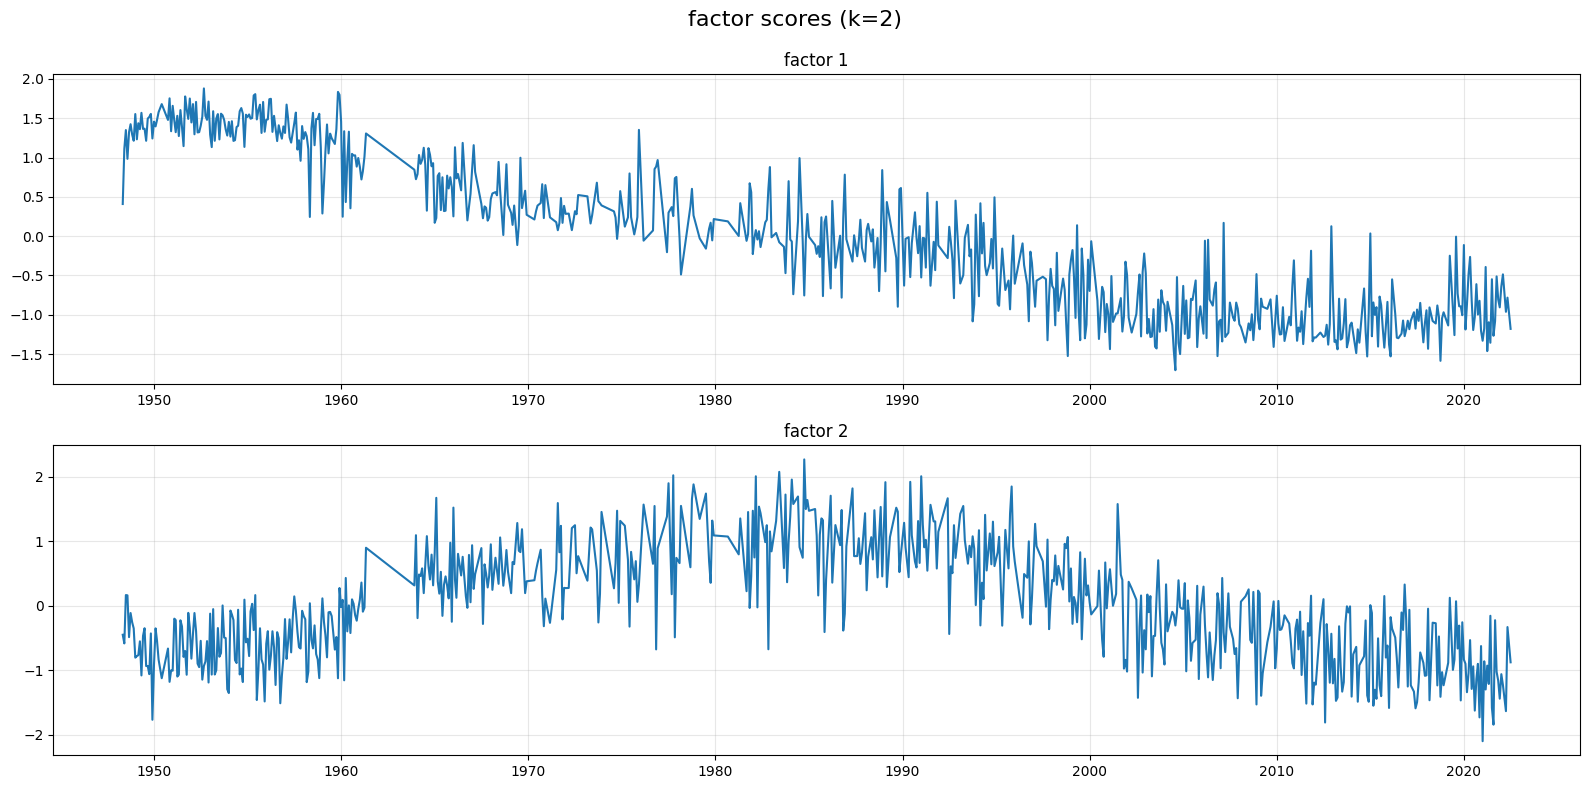

In [21]:
NUM_FACTORS = 2
FIGSIZE = (8,10)

kwargs = dict(
    result=result,
    num_factors=NUM_FACTORS,
)

factor_scores[NUM_FACTORS] = factor_analysis.vis.plot_factor_scores(**kwargs)
plt.show()

# k=3

In [22]:
NUM_FACTORS = 3
loadings = result[NUM_FACTORS]["loadings"]
print(loadings)

          factor_1  factor_2  factor_3
topic                                 
topic_1   0.615947  0.049597 -0.427050
topic_3  -0.005188  0.618618 -0.272306
topic_4   0.228600  0.004998  0.469694
topic_6  -0.655715 -0.053864 -0.053556
topic_7   0.137873  0.448876 -0.294649
topic_9   0.755783 -0.174230 -0.089037
topic_10  0.618940 -0.210724  0.018336
topic_11  0.542999  0.092801  0.328664
topic_12 -0.591607  0.110323  0.022553
topic_13 -0.538250  0.519867  0.339332
topic_14  0.613603  0.081075  0.280061
topic_15 -0.734376 -0.272634 -0.080486
topic_16 -0.789594 -0.379078  0.103732
topic_17  0.878210 -0.194410  0.124792
topic_19 -0.141152 -0.212500 -0.315212
topic_20 -0.533247 -0.237598 -0.119958


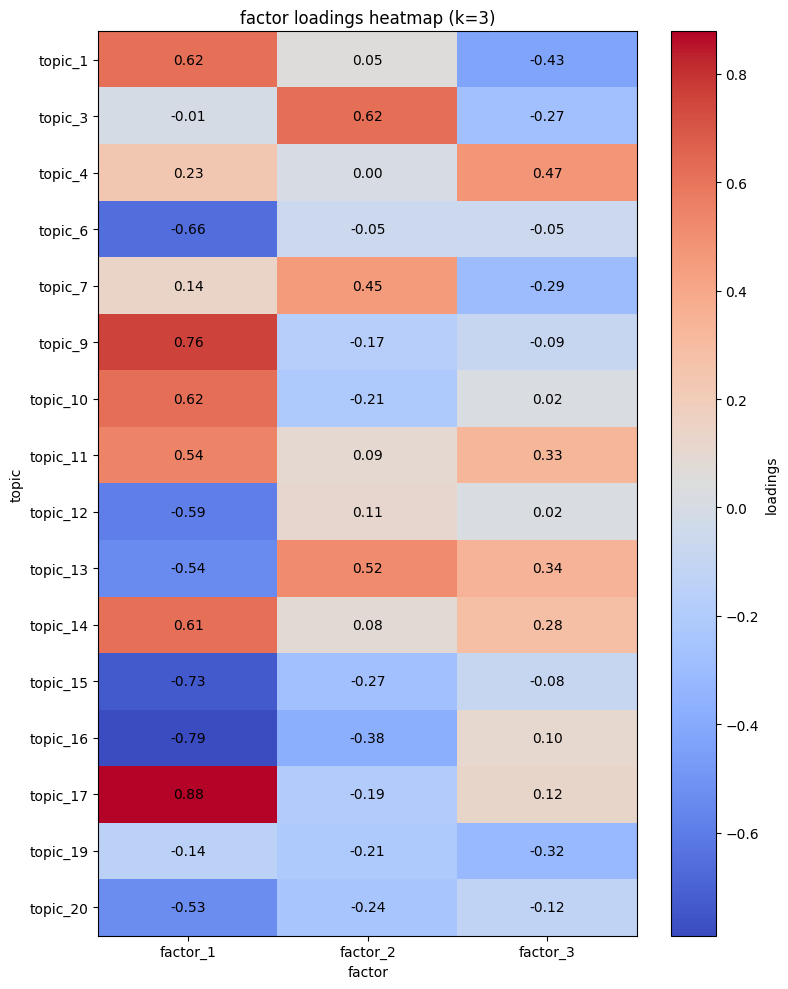

In [23]:
NUM_FACTORS = 3
FIGSIZE = (8,10)

kwargs = dict(
    result=result,
    num_factors=NUM_FACTORS,
    figsize=FIGSIZE,
)

factor_loadings[NUM_FACTORS] = factor_analysis.vis.plot_factor_loadings(**kwargs)
plt.show()

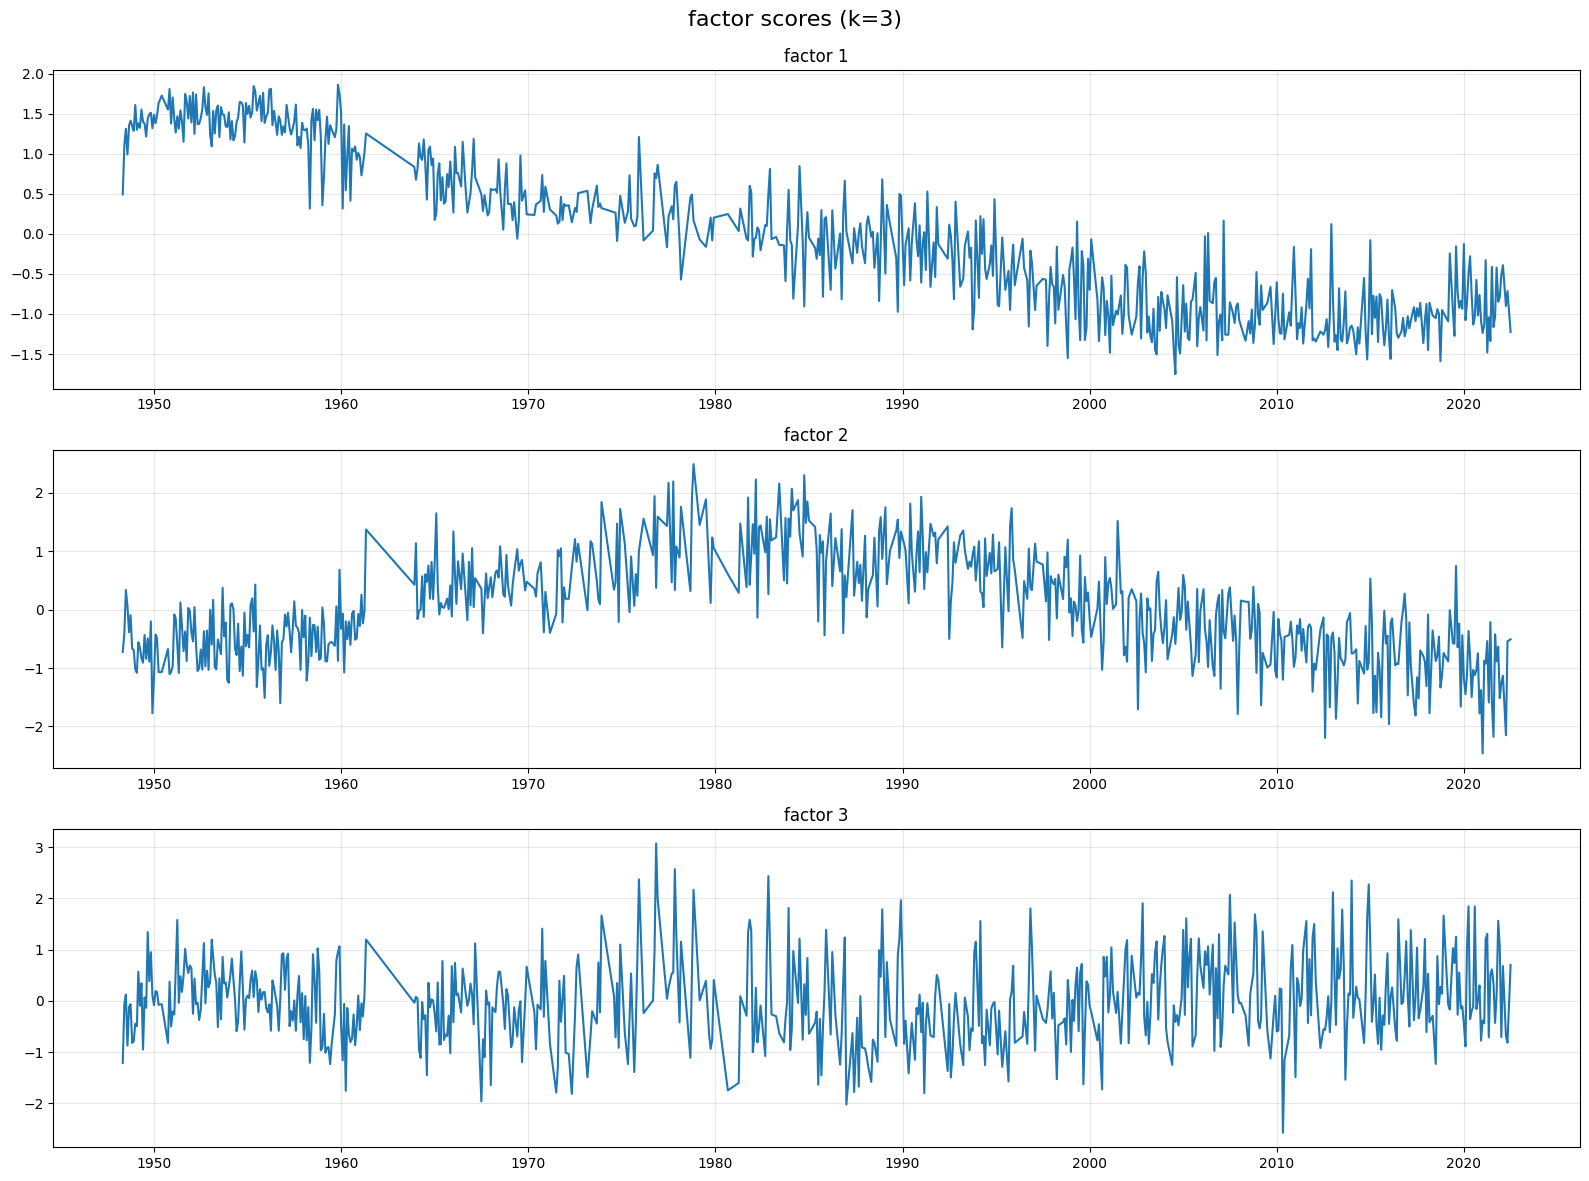

In [24]:
NUM_FACTORS = 3
FIGSIZE = (8,10)

kwargs = dict(
    result=result,
    num_factors=NUM_FACTORS,
)

factor_scores[NUM_FACTORS] = factor_analysis.vis.plot_factor_scores(**kwargs)
plt.show()

# k=4

In [25]:
NUM_FACTORS = 4
loadings = result[NUM_FACTORS]["loadings"]
print(loadings)

          factor_1  factor_2  factor_3  factor_4
topic                                           
topic_1   0.616409  0.125081 -0.385612 -0.160679
topic_3  -0.006200  0.790211 -0.170894  0.289159
topic_4   0.228990 -0.090360  0.437424  0.123329
topic_6  -0.654828 -0.056303 -0.048897 -0.103542
topic_7   0.145258  0.479666 -0.158836 -0.481161
topic_9   0.753994 -0.154885 -0.130673  0.073983
topic_10  0.618696 -0.198163 -0.044571  0.143108
topic_11  0.544895  0.002704  0.345169  0.027775
topic_12 -0.590757  0.082402  0.061265 -0.037819
topic_13 -0.535789  0.390582  0.482046 -0.112784
topic_14  0.613508  0.015132  0.282191  0.129216
topic_15 -0.744715 -0.232971 -0.167507  0.214876
topic_16 -0.787687 -0.383484  0.010513 -0.025639
topic_17  0.878559 -0.225215  0.072399 -0.008769
topic_19 -0.141941 -0.171450 -0.331494 -0.145289
topic_20 -0.534341 -0.198400 -0.172872  0.063180


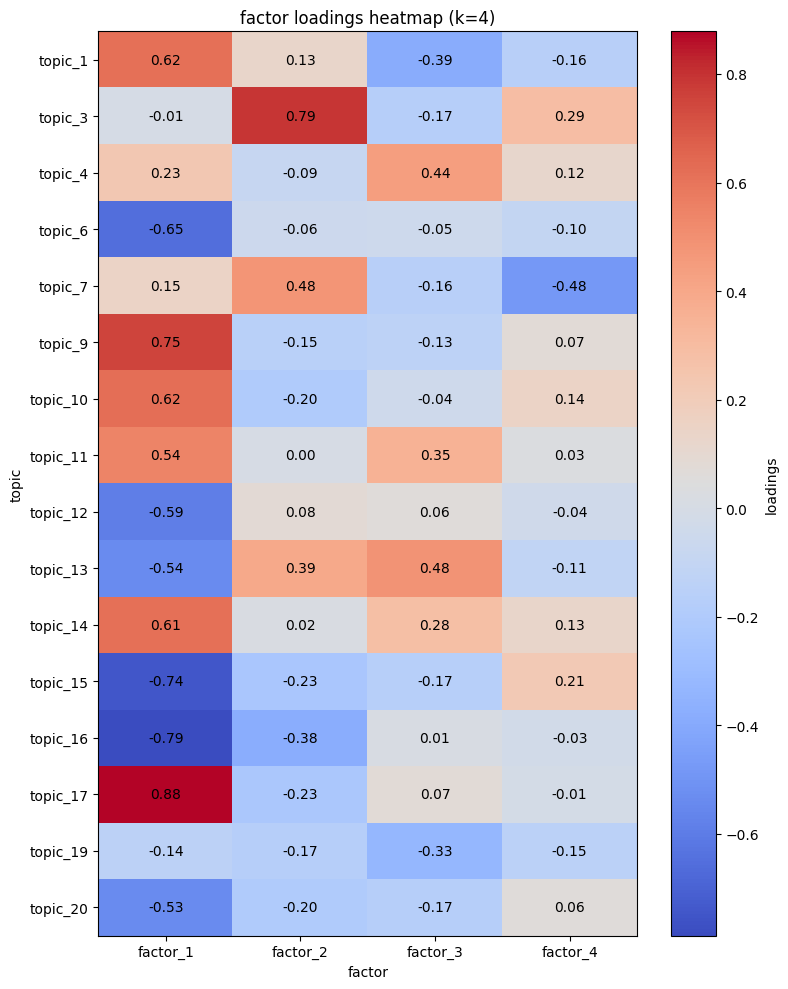

In [26]:
NUM_FACTORS = 4
FIGSIZE = (8,10)

kwargs = dict(
    result=result,
    num_factors=NUM_FACTORS,
    figsize=FIGSIZE,
)

factor_loadings[NUM_FACTORS] = factor_analysis.vis.plot_factor_loadings(**kwargs)
plt.show()

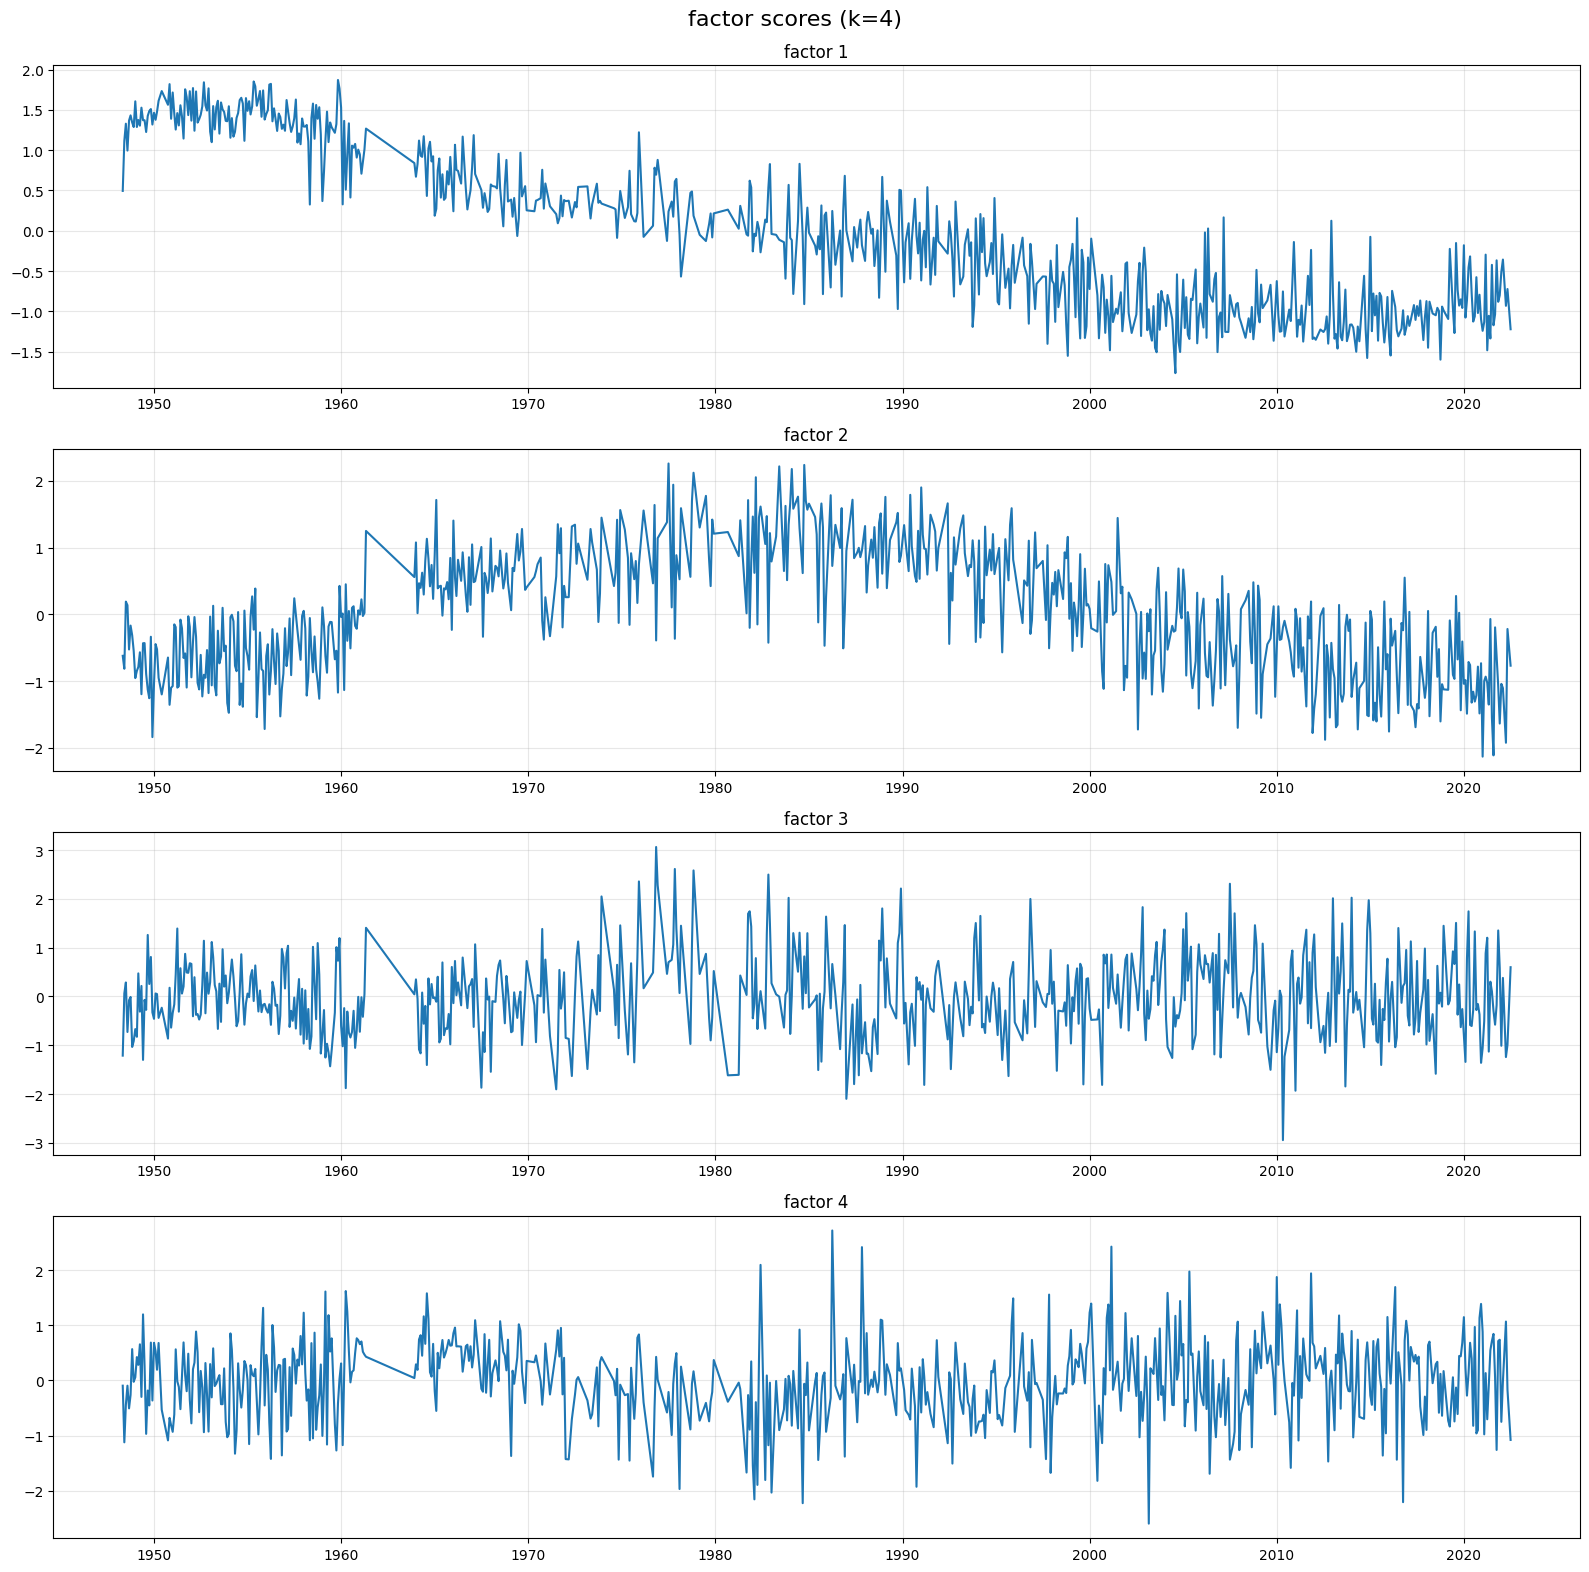

In [27]:
NUM_FACTORS = 4
FIGSIZE = (8,10)

kwargs = dict(
    result=result,
    num_factors=NUM_FACTORS,
)

factor_scores[NUM_FACTORS] = factor_analysis.vis.plot_factor_scores(**kwargs)
plt.show()

# save

In [28]:
NUM_FACTORS = 3

In [29]:
joblib.dump(result[NUM_FACTORS]["model"], "./checkpoints/fa.pkl")

['./checkpoints/fa.pkl']

In [30]:
result[NUM_FACTORS]["loadings"].to_csv("./data/fa_loadings.csv", index=True)
result[NUM_FACTORS]["scores"].to_csv("./data/fa_scores.csv", index=True)